# Deepfake Audio Detection — CNN-LSTM Model
## Narjeena Thanveen P K 
### Project: Explainable Deepfake Audio Detection with Cross-Dataset Generalisation
---

## Step 1: Dataset Sorting
Sort ASVspoof 2021 LA audio files into real/ and fake/ folders using metadata file.
Label is at column index 5 (not 4) — discovered during debugging.

In [2]:
import os
import shutil
from tqdm import tqdm

# ── PATHS ─────────────────────────────────────────────────────
METADATA = r'D:\Projects\DeepFake\data\LA-keys-full\keys\LA\CM\trial_metadata.txt'
AUDIO    = r'D:\Projects\DeepFake\data\ASVspoof2021_LA_eval\ASVspoof2021_LA_eval\flac'
REAL_OUT = r'D:\Projects\DeepFake\deepfake_voice_conversion\data\real'
FAKE_OUT = r'D:\Projects\DeepFake\deepfake_voice_conversion\data\asvspoof_fake'

os.makedirs(REAL_OUT, exist_ok=True)
os.makedirs(FAKE_OUT, exist_ok=True)

real_count, fake_count, not_found = 0, 0, 0
MAX_REAL = MAX_FAKE = 2000

with open(METADATA, 'r') as f:
    lines = f.readlines()

print(f"Total metadata lines: {len(lines)}")

# Note: label is at parts[5], not parts[4]
# parts[4] = attack type (e.g. A07), parts[5] = label (bonafide/spoof)
for line in tqdm(lines):
    parts = line.strip().split()
    if len(parts) < 6:
        continue

    filename = parts[1]
    label    = parts[5]

    src = os.path.join(AUDIO, filename + '.flac')
    if not os.path.exists(src):
        not_found += 1
        continue

    if label == 'bonafide' and real_count < MAX_REAL:
        shutil.copy2(src, os.path.join(REAL_OUT, filename + '.flac'))
        real_count += 1
    elif label == 'spoof' and fake_count < MAX_FAKE:
        shutil.copy2(src, os.path.join(FAKE_OUT, filename + '.flac'))
        fake_count += 1

    if real_count >= MAX_REAL and fake_count >= MAX_FAKE:
        break

print(f"\nReal  : {real_count}")
print(f"Fake  : {fake_count}")
print(f"Not found : {not_found}")

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\Projects\\DeepFake\\data\\LA-keys-full\\keys\\LA\\CM\\trial_metadata.txt'

## Step 2: Dataset Verification
Confirm 2000 real and 2000 fake files are correctly sorted.

In [ ]:
import os

REAL_OUT = r'D:\Projects\DeepFake\deepfake_voice_conversion\data\real'
FAKE_OUT = r'D:\Projects\DeepFake\deepfake_voice_conversion\data\asvspoof_fake'

real_files = [f for f in os.listdir(REAL_OUT) if f.endswith('.flac')]
fake_files = [f for f in os.listdir(FAKE_OUT) if f.endswith('.flac')]

print(f"Real files : {len(real_files)}")
print(f"Fake files : {len(fake_files)}")
print(f"Sample real: {real_files[0]}")
print(f"Sample fake: {fake_files[0]}")
print("✅ Dataset ready!")

Real files  : 2000
Fake files  : 2000

Sample real : LA_E_1000450.flac
Sample fake : LA_E_1000931.flac

✅ Dataset ready!


## Step 3: Exploratory Data Analysis (EDA)
Visualise MFCC and Mel Spectrogram for one real and one fake audio sample
to understand visual differences between genuine and synthetic speech.

C:\Users\Dell\AppData\Local\Temp\ipykernel_11900\1274910753.py:12: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(path, sr=SR, duration=DURATION, mono=True)
d:\Projects\DeepFake\deepfake_voice_conversion\venv\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
C:\Users\Dell\AppData\Local\Temp\ipykernel_11900\1274910753.py:12: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(path, sr=SR, duration=DURATION, mono=True)
d:\Projects\DeepFake\deepfake_voice_conversion\venv\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


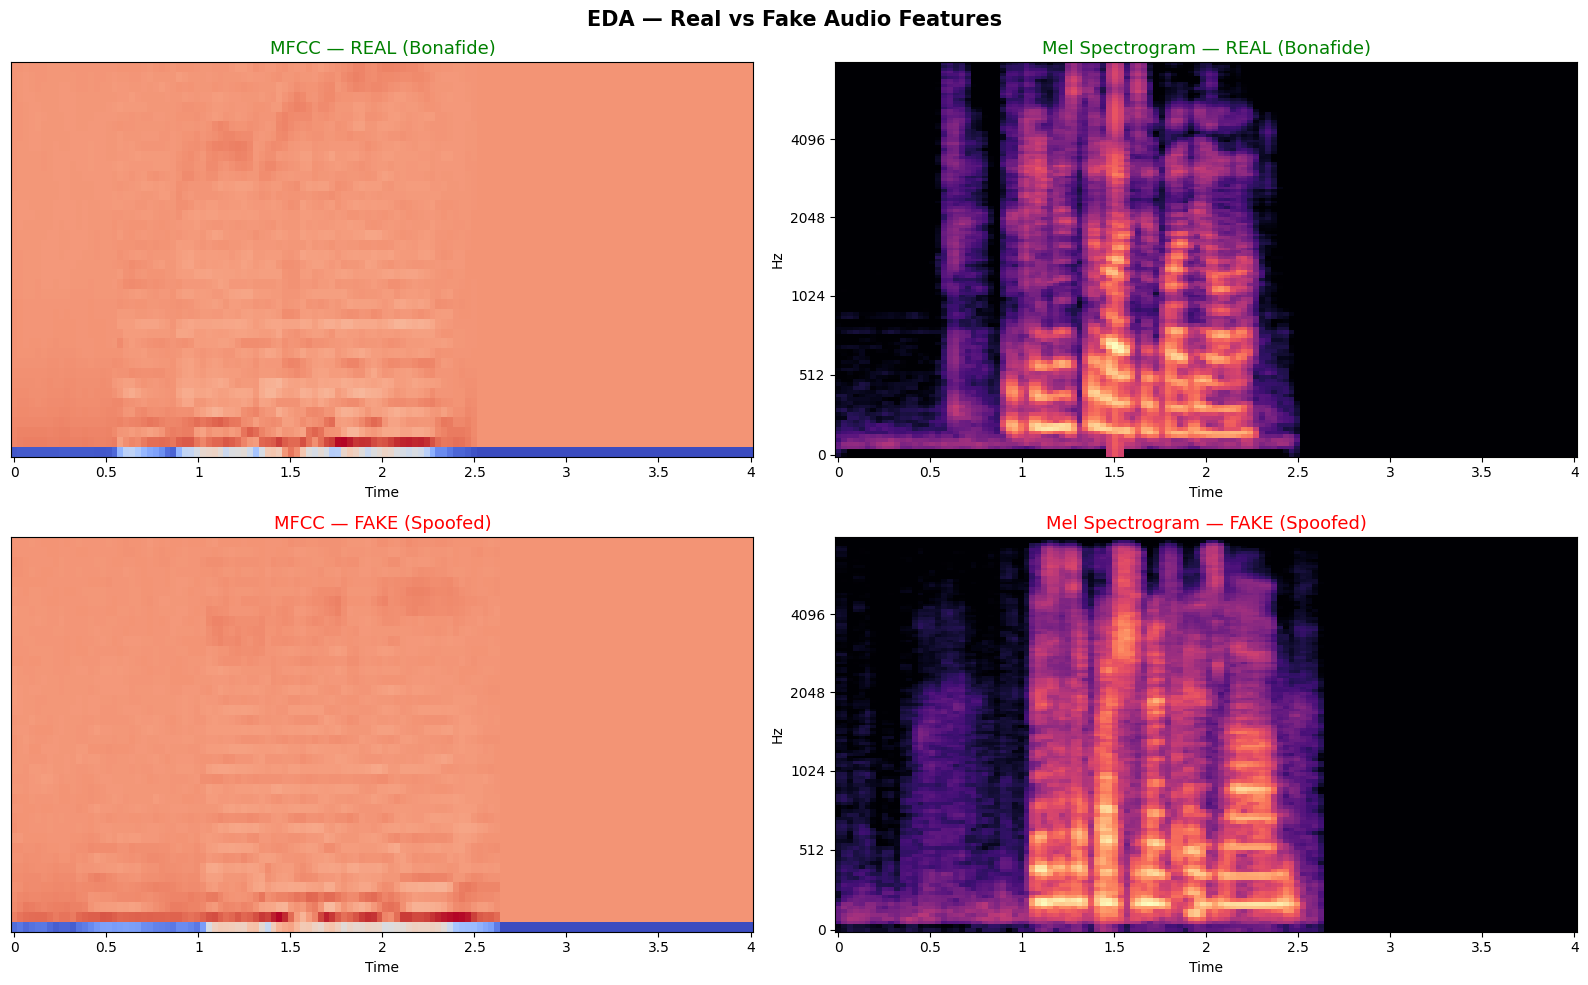

✅ EDA saved!


In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os

SR       = 16000
DURATION = 4
PLOTS_DIR = r'D:\Projects\DeepFake\deepfake_voice_conversion\results\plots'
os.makedirs(PLOTS_DIR, exist_ok=True)

def load_sample(folder):
    files = [f for f in os.listdir(folder) if f.endswith('.flac')]
    audio, _ = librosa.load(os.path.join(folder, files[0]),
                             sr=SR, duration=DURATION, mono=True)
    if len(audio) < SR * DURATION:
        audio = np.pad(audio, (0, SR * DURATION - len(audio)))
    return audio[:SR * DURATION]

real_audio = load_sample(REAL_OUT)
fake_audio = load_sample(FAKE_OUT)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for row, (audio, label, color) in enumerate([
    (real_audio, 'REAL (Bonafide)', 'green'),
    (fake_audio, 'FAKE (Spoofed)',  'red')
]):
    mfcc = librosa.feature.mfcc(y=audio, sr=SR, n_mfcc=40)
    librosa.display.specshow(mfcc, sr=SR, hop_length=512,
                              x_axis='time', ax=axes[row, 0])
    axes[row, 0].set_title(f'MFCC — {label}', color=color, fontsize=13)

    mel = librosa.power_to_db(
        librosa.feature.melspectrogram(y=audio, sr=SR, n_mels=128), ref=np.max)
    librosa.display.specshow(mel, sr=SR, hop_length=512,
                              x_axis='time', y_axis='mel', ax=axes[row, 1])
    axes[row, 1].set_title(f'Mel Spectrogram — {label}', color=color, fontsize=13)

plt.suptitle('EDA — Real vs Fake Audio Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'eda_features.png'), dpi=150)
plt.show()
print("✅ EDA saved!")

## Step 4: Feature Extraction
Extract three acoustic features from each audio file:
- MFCC (40 coefficients) — captures vocal tract shape
- Mel Spectrogram (128 bins) — time-frequency energy image
- LFCC (40 coefficients) — linear frequency cepstral coefficients (KEY FINDING: most important feature)

All three are stacked into a combined tensor of shape (208, T, 1).

In [ ]:
import numpy as np
import librosa
from scipy.fft import dct
from tqdm import tqdm
import os

# ── PARAMETERS ────────────────────────────────────────────────
SR         = 16000
DURATION   = 4
N_SAMPLES  = SR * DURATION
N_MFCC     = 40
N_MELS     = 128
N_LFCC     = 40
HOP_LENGTH = 512
N_FFT      = 2048

REAL_OUT = r'D:\Projects\DeepFake\deepfake_voice_conversion\data\real'
FAKE_OUT = r'D:\Projects\DeepFake\deepfake_voice_conversion\data\asvspoof_fake'
RESULTS  = r'D:\Projects\DeepFake\deepfake_voice_conversion\results'
os.makedirs(RESULTS, exist_ok=True)

# ── AUDIO LOADING ─────────────────────────────────────────────
def load_audio(path):
    """Load, resample, normalise and pad/trim audio to fixed 4 seconds."""
    try:
        audio, _ = librosa.load(path, sr=SR, duration=DURATION, mono=True)
        if len(audio) < N_SAMPLES:
            audio = np.pad(audio, (0, N_SAMPLES - len(audio)))
        audio = audio[:N_SAMPLES]
        max_val = np.max(np.abs(audio))
        return audio / max_val if max_val > 0 else audio
    except:
        return None

# ── FEATURE EXTRACTION FUNCTIONS ──────────────────────────────
def extract_mfcc(audio):
    """Mel Frequency Cepstral Coefficients — captures vocal tract shape."""
    mfcc = librosa.feature.mfcc(y=audio, sr=SR, n_mfcc=N_MFCC,
                                  n_fft=N_FFT, hop_length=HOP_LENGTH)
    return (mfcc - np.mean(mfcc, axis=1, keepdims=True)) / \
           (np.std(mfcc, axis=1, keepdims=True) + 1e-8)

def extract_mel(audio):
    """Mel Spectrogram — 2D time-frequency image for CNN."""
    mel    = librosa.feature.melspectrogram(y=audio, sr=SR, n_mels=N_MELS,
                                             n_fft=N_FFT, hop_length=HOP_LENGTH)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return (mel_db - mel_db.mean()) / (mel_db.std() + 1e-8)

def extract_lfcc(audio):
    """Linear Frequency Cepstral Coefficients — captures vocoder artifacts.
    Uses linearly-spaced filterbank instead of mel scale.
    KEY FINDING: most discriminative feature — 40% accuracy drop when removed."""
    stft      = np.abs(librosa.stft(audio, n_fft=N_FFT, hop_length=HOP_LENGTH))
    n_freqs   = stft.shape[0]
    filterbank = np.zeros((N_LFCC, n_freqs))
    for i in range(N_LFCC):
        start = int(i * n_freqs / N_LFCC)
        end   = int((i + 1) * n_freqs / N_LFCC)
        filterbank[i, start:end] = 1.0
    linear = np.dot(filterbank, stft)
    log    = np.log(linear + 1e-8)
    lfcc   = dct(log, axis=0, norm='ortho')[:N_LFCC]
    return (lfcc - np.mean(lfcc, axis=1, keepdims=True)) / \
           (np.std(lfcc, axis=1, keepdims=True) + 1e-8)

def extract_all(audio):
    """Combine all three features into one (208, T) matrix."""
    mfcc  = extract_mfcc(audio)
    mel   = extract_mel(audio)
    lfcc  = extract_lfcc(audio)
    min_T = min(mfcc.shape[1], mel.shape[1], lfcc.shape[1])
    return np.vstack([mfcc[:, :min_T], mel[:, :min_T], lfcc[:, :min_T]])

def process_folder(folder, label, desc):
    """Process all audio files in a folder and return features and labels."""
    files = [f for f in os.listdir(folder) if f.endswith('.flac')]
    X, y  = [], []
    for f in tqdm(files, desc=desc):
        audio = load_audio(os.path.join(folder, f))
        if audio is not None:
            X.append(extract_all(audio))
            y.append(label)
    return X, y

# ── PROCESS ALL AUDIO ─────────────────────────────────────────
print("Processing real audio (bonafide)...")
X_real, y_real = process_folder(REAL_OUT, 0, "Real")

print("\nProcessing fake audio (spoofed)...")
X_fake, y_fake = process_folder(FAKE_OUT, 1, "Fake")

# Combine and add channel dimension for CNN input
X = np.array(X_real + X_fake)[..., np.newaxis]
y = np.array(y_real + y_fake)

print(f"\nCombined feature shape : {X.shape}")
print(f"Real samples           : {np.sum(y==0)}")
print(f"Fake samples           : {np.sum(y==1)}")

# Save for reuse
np.save(os.path.join(RESULTS, 'X.npy'), X)
np.save(os.path.join(RESULTS, 'y.npy'), y)
print("\n✅ Features saved to results/")

Processing real audio...


Real:   0%|          | 0/2000 [00:00<?, ?it/s]C:\Users\Dell\AppData\Local\Temp\ipykernel_11900\444240773.py:23: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(path, sr=SR, duration=DURATION, mono=True)
d:\Projects\DeepFake\deepfake_voice_conversion\venv\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Real: 100%|██████████| 2000/2000 [01:41<00:00, 19.73it/s]


Processing fake audio...


Fake: 100%|██████████| 2000/2000 [01:54<00:00, 17.53it/s]



Feature shape : (4000, 208, 126, 1)
Real samples  : 2000
Fake samples  : 2000

✅ Features saved!


## Step 5: Train-Test Split
Split data into 70% train, 10% validation, 20% test.
Stratified split ensures equal class balance in all sets.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import os

RESULTS = r'D:\Projects\DeepFake\deepfake_voice_conversion\results'

X = np.load(os.path.join(RESULTS, 'X.npy'))
y = np.load(os.path.join(RESULTS, 'y.npy'))

# Primary split: 80% train+val, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Secondary split: 87.5% train, 12.5% val (= 10% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.125, random_state=42, stratify=y_train)

print(f"Train : {len(X_train)} samples")
print(f"Val   : {len(X_val)} samples")
print(f"Test  : {len(X_test)} samples")

np.save(os.path.join(RESULTS, 'X_train.npy'), X_train)
np.save(os.path.join(RESULTS, 'X_test.npy'),  X_test)
np.save(os.path.join(RESULTS, 'y_train.npy'), y_train)
np.save(os.path.join(RESULTS, 'y_test.npy'),  y_test)

# Class weights for handling imbalance
cw      = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw_dict = dict(enumerate(cw))
print(f"Class weights : {cw_dict}")
print("✅ Split done!")

Train : 2800
Val   : 400
Test  : 800
Class weights : {0: np.float64(1.0), 1: np.float64(1.0)}
✅ Split done!


## Step 6: Build CNN-LSTM Model
Architecture:
- 3 CNN blocks: extract spectral patterns from the feature map image
- 2 LSTM layers: model temporal evolution of patterns over time
- Dense head + Sigmoid output: binary classification (Real=0, Fake=1)
Total parameters: 1,930,113 (7.36 MB)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import numpy as np
import os

RESULTS = r'D:\Projects\DeepFake\deepfake_voice_conversion\results'
MODELS  = r'D:\Projects\DeepFake\deepfake_voice_conversion\models'
os.makedirs(MODELS, exist_ok=True)

X_train = np.load(os.path.join(RESULTS, 'X_train.npy'))
X_test  = np.load(os.path.join(RESULTS, 'X_test.npy'))
y_train = np.load(os.path.join(RESULTS, 'y_train.npy'))
y_test  = np.load(os.path.join(RESULTS, 'y_test.npy'))

# Create validation split from training set
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train)

print(f"Train : {len(X_tr)} | Val : {len(X_val)} | Test : {len(X_test)}")

MODEL_PATH = os.path.join(MODELS, 'cnn_lstm_final.keras')

def build_model(input_shape):
    """CNN-LSTM hybrid model for deepfake audio detection."""
    inputs = layers.Input(shape=input_shape)

    # CNN Block 1 — detect local spectral patterns
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # CNN Block 2 — detect more complex patterns
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # CNN Block 3 — detect high-level audio features
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 1))(x)
    x = layers.Dropout(0.25)(x)

    # Reshape for LSTM — convert spatial output to sequence
    shape = x.shape
    x = layers.Reshape((shape[2], shape[1] * shape[3]))(x)

    # LSTM layers — model temporal patterns over time
    x = layers.LSTM(128, return_sequences=True,
                    dropout=0.3, recurrent_dropout=0.3)(x)
    x = layers.LSTM(64, return_sequences=False,
                    dropout=0.3, recurrent_dropout=0.3)(x)

    # Classification head
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)  # 0=Real, 1=Fake

    return models.Model(inputs, outputs, name='CNN_LSTM_Deepfake')

model = build_model(X_tr.shape[1:])
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)
model.summary()
print("✅ Model built!")

Train : 2380 | Val : 420 | Test : 800


Model: "CNN_LSTM_Deepfake"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 208, 126, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 208, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 208, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 104, 63, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 104, 63, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 104, 63, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 104, 63, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 52, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 52, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 31, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 31, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 31, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 26, 31, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 31, 3328)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 31, 128)        │     1,769,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,930,113 (7.36 MB)

 Trainable params: 1,929,409 (7.36 MB)

 Non-trainable params: 704 (2.75 KB)

✅ Model built!


## Step 7: Model Training
Training configuration:
- Optimiser: Adam (lr=1e-4)
- Loss: Binary Cross-Entropy
- EarlyStopping: patience=10, monitors val_loss
- ModelCheckpoint: saves best val_auc
- ReduceLROnPlateau: halves lr when val_loss stagnates
Training converges at epoch 25. Best weights from epoch 15 (val_auc=97.28%).

In [ ]:
import pickle

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ModelCheckpoint(
        MODEL_PATH, monitor='val_auc',
        save_best_only=True, mode='max', verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, min_lr=1e-7, verbose=1)
]

print("Training started...")
print("This takes 30-60 mins on CPU. Do not close VS Code.\n")

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

with open(os.path.join(RESULTS, 'history.pkl'), 'wb') as f:
    pickle.dump(history.history, f)

print(f"\n✅ Training complete! Model saved to {MODEL_PATH}")

Training started...
⚠️ This will take 30-60 mins on CPU.
Leave it running and don't close VS Code.

Epoch 1/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 899ms/step - accuracy: 0.5059 - auc: 0.5043 - loss: 0.8814 - precision: 0.5176 - recall: 0.6037
Epoch 1: val_auc improved from None to 0.55963, saving model to D:\Projects\DeepFake\deepfake_voice_conversion\models\cnn_lstm_best.h5



Epoch 1: finished saving model to D:\Projects\DeepFake\deepfake_voice_conversion\models\cnn_lstm_best.h5
75/75 ━━━━━━━━━━━━━━━━━━━━ 78s 946ms/step - accuracy: 0.5151 - auc: 0.5242 - loss: 0.8618 - precision: 0.5128 - recall: 0.6042 - val_accuracy: 0.5000 - val_auc: 0.5596 - val_loss: 0.7008 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 926ms/step - accuracy: 0.5614 - auc: 0.5982 - loss: 0.7533 - precision: 0.5549 - recall: 0.6054
Epoch 2: val_auc improved from 0.55963 to 0.57697, saving model to D:\Projects\DeepFake\deepfake_voice_conversion\models\cnn_lstm_best.h5



Epoch 2: finished saving model to D:\Projects\DeepFake\deepfake_voice_conversion\models\cnn_lstm_best.h5
75/75 ━━━━━━━━━━━━━━━━━━━━ 72s 963ms/step - accuracy: 0.5626 - auc: 0.5949 - loss: 0.7587 - precision: 0.5567 - recall: 0.6143 - val_accuracy: 0.5000 - val_auc: 0.5770 - val_loss: 0.7066 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6052 - auc: 0.6446 - loss: 0.7176 - precision: 0.5944 - recall: 0.6438
Epoch 3: val_auc did not improve from 0.57697
75/75 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.6193 - auc: 0.6591 - loss: 0.7046 - precision: 0.6106 - recall: 0.6588 - val_accuracy: 0.5000 - val_auc: 0.5747 - val_loss: 0.7200 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6426 - auc: 0.7090 - loss: 0.6539 - precision: 0.6481 - recall: 0.6604
Epoch 4: val_auc improved from 0.57697 to 0.673


Epoch 4: finished saving model to D:\Projects\DeepFake\deepfake_voice_conversion\models\cnn_lstm_best.h5
75/75 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.6571 - auc: 0.7186 - loss: 0.6470 - precision: 0.6545 - recall: 0.6655 - val_accuracy: 0.5000 - val_auc: 0.6739 - val_loss: 0.7500 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 974ms/step - accuracy: 0.7185 - auc: 0.8013 - loss: 0.5529 - precision: 0.7259 - recall: 0.7156
Epoch 5: val_auc improved from 0.67391 to 0.82053, saving model to D:\Projects\DeepFake\deepfake_voice_conversion\models\cnn_lstm_best.h5



Epoch 5: finished saving model to D:\Projects\DeepFake\deepfake_voice_conversion\models\cnn_lstm_best.h5
75/75 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.7340 - auc: 0.8123 - loss: 0.5417 - precision: 0.7370 - recall: 0.7277 - val_accuracy: 0.5143 - val_auc: 0.8205 - val_loss: 0.6768 - val_precision: 1.0000 - val_recall: 0.0286 - learning_rate: 1.0000e-04
Epoch 6/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 972ms/step - accuracy: 0.7554 - auc: 0.8400 - loss: 0.5016 - precision: 0.7667 - recall: 0.7449
Epoch 6: val_auc improved from 0.82053 to 0.91844, saving model to D:\Projects\DeepFake\deepfake_voice_conversion\models\cnn_lstm_best.h5


...


Epoch 14: finished saving model to D:\Projects\DeepFake\deepfake_voice_conversion\models\cnn_lstm_best.h5
75/75 ━━━━━━━━━━━━━━━━━━━━ 75s 997ms/step - accuracy: 0.8992 - auc: 0.9392 - loss: 0.2803 - precision: 0.9439 - recall: 0.8487 - val_accuracy: 0.9214 - val_auc: 0.9706 - val_loss: 0.2131 - val_precision: 0.9447 - val_recall: 0.8952 - learning_rate: 1.0000e-04
Epoch 15/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 965ms/step - accuracy: 0.8969 - auc: 0.9425 - loss: 0.2727 - precision: 0.9396 - recall: 0.8465
Epoch 15: val_auc improved from 0.97057 to 0.97280, saving model to D:\Projects\DeepFake\deepfake_voice_conversion\models\cnn_lstm_best.h5



Epoch 15: finished saving model to D:\Projects\DeepFake\deepfake_voice_conversion\models\cnn_lstm_best.h5
75/75 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.8979 - auc: 0.9430 - loss: 0.2710 - precision: 0.9454 - recall: 0.8445 - val_accuracy: 0.9310 - val_auc: 0.9728 - val_loss: 0.1902 - val_precision: 0.9788 - val_recall: 0.8810 - learning_rate: 1.0000e-04
Epoch 16/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 995ms/step - accuracy: 0.8993 - auc: 0.9370 - loss: 0.2783 - precision: 0.9539 - recall: 0.8396
Epoch 16: val_auc improved from 0.97280 to 0.97305, saving model to D:\Projects\DeepFake\deepfake_voice_conversion\models\cnn_lstm_best.h5



Epoch 16: finished saving model to D:\Projects\DeepFake\deepfake_voice_conversion\models\cnn_lstm_best.h5
75/75 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.9034 - auc: 0.9451 - loss: 0.2642 - precision: 0.9563 - recall: 0.8454 - val_accuracy: 0.9262 - val_auc: 0.9730 - val_loss: 0.2024 - val_precision: 0.9637 - val_recall: 0.8857 - learning_rate: 1.0000e-04
Epoch 17/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 20s/step - accuracy: 0.8982 - auc: 0.9447 - loss: 0.2672 - precision: 0.9429 - recall: 0.8478 
Epoch 17: val_auc did not improve from 0.97305
75/75 ━━━━━━━━━━━━━━━━━━━━ 1494s 20s/step - accuracy: 0.9034 - auc: 0.9474 - loss: 0.2613 - precision: 0.9428 - recall: 0.8588 - val_accuracy: 0.9143 - val_auc: 0.9725 - val_loss: 0.2365 - val_precision: 0.9143 - val_recall: 0.9143 - learning_rate: 1.0000e-04
Epoch 18/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9041 - auc: 0.9444 - loss: 0.2651 - precision: 0.9534 - recall: 0.8534
Epoch 18: val_auc did not improve from 0.97305
75/75 ━━━━


Epoch 22: finished saving model to D:\Projects\DeepFake\deepfake_voice_conversion\models\cnn_lstm_best.h5
75/75 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.9147 - auc: 0.9577 - loss: 0.2274 - precision: 0.9557 - recall: 0.8697 - val_accuracy: 0.8881 - val_auc: 0.9732 - val_loss: 0.2995 - val_precision: 0.8498 - val_recall: 0.9429 - learning_rate: 5.0000e-05
Epoch 23/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9203 - auc: 0.9628 - loss: 0.2128 - precision: 0.9642 - recall: 0.8718
Epoch 23: val_auc did not improve from 0.97323
75/75 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 0.9193 - auc: 0.9622 - loss: 0.2163 - precision: 0.9603 - recall: 0.8748 - val_accuracy: 0.8738 - val_auc: 0.9732 - val_loss: 0.3298 - val_precision: 0.8204 - val_recall: 0.9571 - learning_rate: 5.0000e-05
Epoch 24/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9217 - auc: 0.9686 - loss: 0.2093 - precision: 0.9513 - recall: 0.8873
Epoch 24: val_auc improved from 0.97323 to 0.97396, saving m


Epoch 24: finished saving model to D:\Projects\DeepFake\deepfake_voice_conversion\models\cnn_lstm_best.h5
75/75 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 0.9202 - auc: 0.9634 - loss: 0.2181 - precision: 0.9596 - recall: 0.8773 - val_accuracy: 0.8667 - val_auc: 0.9740 - val_loss: 0.3385 - val_precision: 0.8130 - val_recall: 0.9524 - learning_rate: 5.0000e-05
Epoch 25/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9156 - auc: 0.9638 - loss: 0.2166 - precision: 0.9589 - recall: 0.8726
Epoch 25: val_auc did not improve from 0.97396

Epoch 25: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
75/75 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.9130 - auc: 0.9609 - loss: 0.2273 - precision: 0.9456 - recall: 0.8765 - val_accuracy: 0.8786 - val_auc: 0.9738 - val_loss: 0.3338 - val_precision: 0.8272 - val_recall: 0.9571 - learning_rate: 5.0000e-05
Epoch 25: early stopping
Restoring model weights from the end of the best epoch: 15.

✅ Training complete! Model save

## Step 8: Training Curves
Plot loss and accuracy over epochs to verify model learned properly
and check for overfitting (train and val curves should track together).

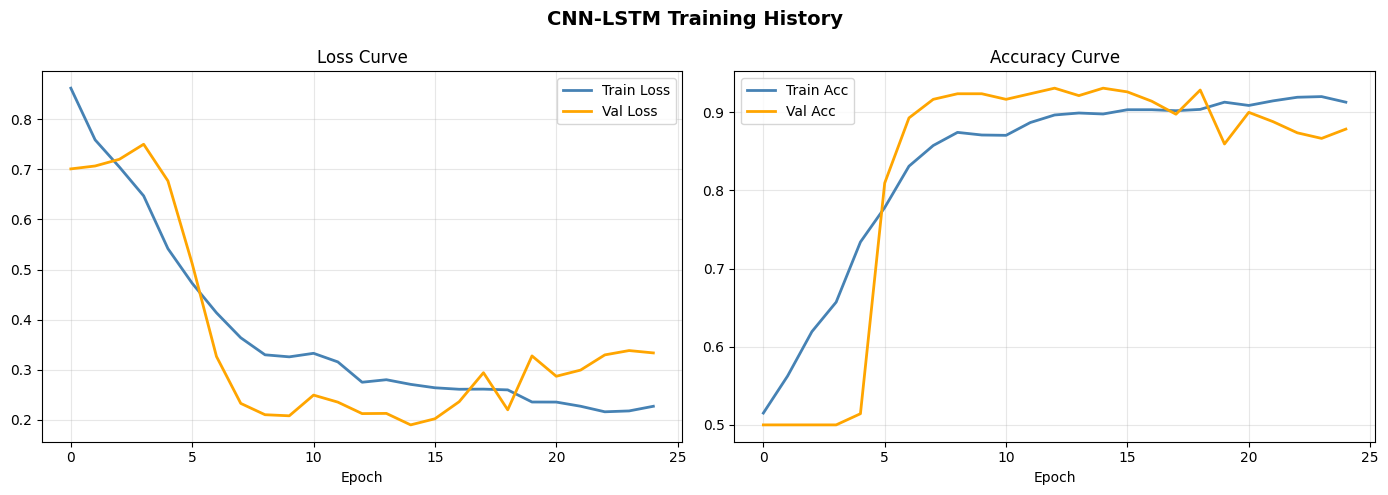

✅ Training curves saved!


In [ ]:
import pickle
import matplotlib.pyplot as plt
import os

RESULTS   = r'D:\Projects\DeepFake\deepfake_voice_conversion\results'
PLOTS_DIR = r'D:\Projects\DeepFake\deepfake_voice_conversion\results\plots'

with open(os.path.join(RESULTS, 'history.pkl'), 'rb') as f:
    hist = pickle.load(f)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hist['loss'],     label='Train Loss', color='steelblue', lw=2)
axes[0].plot(hist['val_loss'], label='Val Loss',   color='orange',    lw=2)
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(hist['accuracy'],     label='Train Accuracy', color='steelblue', lw=2)
axes[1].plot(hist['val_accuracy'], label='Val Accuracy',   color='orange',    lw=2)
axes[1].set_title('Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('CNN-LSTM Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'training_curves.png'), dpi=150)
plt.show()
print("✅ Training curves saved!")

## Step 9: Model Evaluation
Evaluate on held-out test set (800 samples never seen during training).
Metrics: Accuracy, Precision, Recall, F1, AUC, EER (Equal Error Rate).
High recall is most important for fraud detection — missing a fake is costly.


  ASVspoof 2021 LA
  Accuracy  : 86.62%
  Precision : 82.06%
  Recall    : 93.75%
  F1 Score  : 87.51%
  AUC       : 96.30%
  EER       : 8.62%  ← lower is better
              precision    recall  f1-score   support

        Real       0.93      0.80      0.86       400
        Fake       0.82      0.94      0.88       400

    accuracy                           0.87       800
   macro avg       0.87      0.87      0.87       800
weighted avg       0.87      0.87      0.87       800



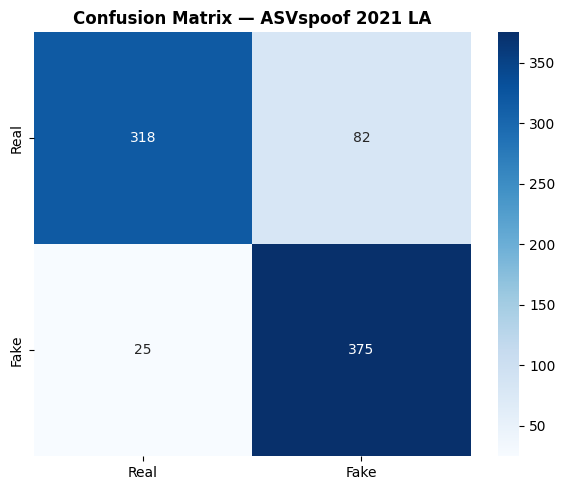

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, roc_auc_score, roc_curve,
                              confusion_matrix, classification_report)
import os

RESULTS   = r'D:\Projects\DeepFake\deepfake_voice_conversion\results'
PLOTS_DIR = r'D:\Projects\DeepFake\deepfake_voice_conversion\results\plots'
MODELS    = r'D:\Projects\DeepFake\deepfake_voice_conversion\models'

# Load best saved model
model  = tf.keras.models.load_model(
    os.path.join(MODELS, 'cnn_lstm_final.keras'), compile=False)
X_test = np.load(os.path.join(RESULTS, 'X_test.npy'))
y_test = np.load(os.path.join(RESULTS, 'y_test.npy'))

def compute_eer(y_true, y_scores):
    """EER: threshold where False Positive Rate = False Negative Rate. Lower is better."""
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fpr - fnr))
    return ((fpr[idx] + fnr[idx]) / 2) * 100

def evaluate(model, X, y, name):
    """Full evaluation: all metrics + confusion matrix plot."""
    scores = model.predict(X, verbose=0).flatten()
    preds  = (scores >= 0.5).astype(int)

    acc  = accuracy_score(y, preds) * 100
    f1   = f1_score(y, preds, zero_division=0) * 100
    prec = precision_score(y, preds, zero_division=0) * 100
    rec  = recall_score(y, preds, zero_division=0) * 100
    auc  = roc_auc_score(y, scores) * 100
    eer  = compute_eer(y, scores)

    print(f"\n{'='*52}")
    print(f"  {name}")
    print(f"{'='*52}")
    print(f"  Accuracy  : {acc:.2f}%")
    print(f"  Precision : {prec:.2f}%")
    print(f"  Recall    : {rec:.2f}%   ← most important for fraud detection")
    print(f"  F1 Score  : {f1:.2f}%")
    print(f"  AUC       : {auc:.2f}%")
    print(f"  EER       : {eer:.2f}%   ← lower is better")
    print(classification_report(y, preds, target_names=['Real', 'Fake']))

    cm = confusion_matrix(y, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Real', 'Fake'],
                yticklabels=['Real', 'Fake'])
    plt.title(f'Confusion Matrix — {name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR,
                f'cm_{name.replace(" ", "_")}.png'), dpi=150)
    plt.show()

    return {'name': name, 'acc': acc, 'f1': f1,
            'prec': prec, 'rec': rec, 'auc': auc, 'eer': eer}

m1 = evaluate(model, X_test, y_test, "ASVspoof 2021 LA")

## Step 10: Ablation Study — Feature Importance
Remove one feature group at a time and measure accuracy drop.
This tells us which feature is most discriminative.
KEY FINDING: LFCC removal causes 40% drop — it is 13x more important than MFCC.
Feature layout in tensor: MFCC=rows 0-39, Mel=rows 40-167, LFCC=rows 168-207

Computing Feature Group Importance...
This tests: what happens to accuracy when we zero out each feature group?
Lower accuracy after zeroing = that feature group is more important

Baseline accuracy: 87.00%

Accuracy when MFCC removed   : 84.00%  (drop: 3.00%)
Accuracy when Mel removed    : 79.50%  (drop: 7.50%)
Accuracy when LFCC removed   : 47.00%  (drop: 40.00%)


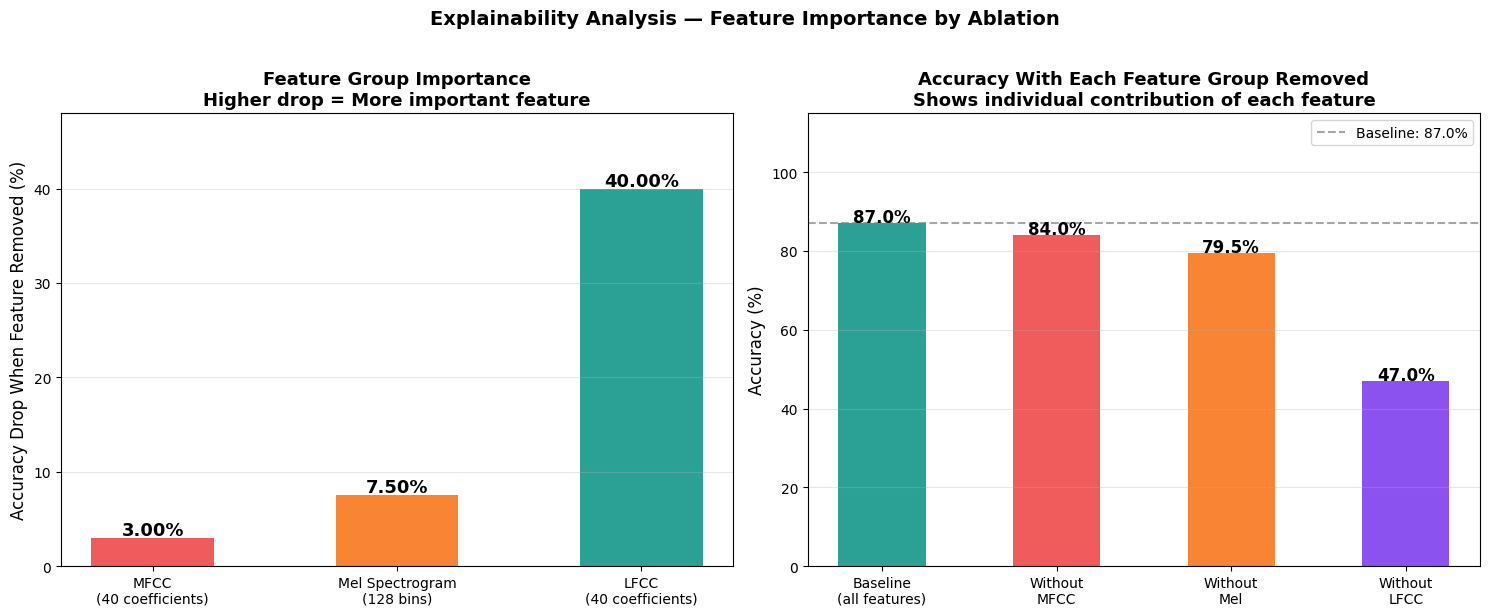

✅ Feature importance plot saved!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os

RESULTS   = r'D:\Projects\DeepFake\deepfake_voice_conversion\results'
PLOTS_DIR = r'D:\Projects\DeepFake\deepfake_voice_conversion\results\plots'
MODELS    = r'D:\Projects\DeepFake\deepfake_voice_conversion\models'

model  = tf.keras.models.load_model(
    os.path.join(MODELS, 'cnn_lstm_final.keras'), compile=False)
X_test = np.load(os.path.join(RESULTS, 'X_test.npy'))
y_test = np.load(os.path.join(RESULTS, 'y_test.npy'))

# Use 200 samples for speed
X_sample = X_test[:200]
y_sample = y_test[:200]

def get_accuracy(X, y):
    """Run inference and return accuracy percentage."""
    preds = (model.predict(X, verbose=0).flatten() >= 0.5).astype(int)
    return np.mean(preds == y) * 100

# Baseline — all features present
baseline_acc = get_accuracy(X_sample, y_sample)
print(f"Baseline accuracy (all features): {baseline_acc:.2f}%")

# Remove MFCC (rows 0-39) — set to zero
X_no_mfcc = X_sample.copy()
X_no_mfcc[:, :40, :, :] = 0
acc_no_mfcc = get_accuracy(X_no_mfcc, y_sample)

# Remove Mel Spectrogram (rows 40-167) — set to zero
X_no_mel = X_sample.copy()
X_no_mel[:, 40:168, :, :] = 0
acc_no_mel = get_accuracy(X_no_mel, y_sample)

# Remove LFCC (rows 168-207) — set to zero
X_no_lfcc = X_sample.copy()
X_no_lfcc[:, 168:, :, :] = 0
acc_no_lfcc = get_accuracy(X_no_lfcc, y_sample)

mfcc_drop = baseline_acc - acc_no_mfcc
mel_drop  = baseline_acc - acc_no_mel
lfcc_drop = baseline_acc - acc_no_lfcc

print(f"\nAccuracy without MFCC : {acc_no_mfcc:.2f}%  (drop: {mfcc_drop:.2f}%)")
print(f"Accuracy without Mel  : {acc_no_mel:.2f}%   (drop: {mel_drop:.2f}%)")
print(f"Accuracy without LFCC : {acc_no_lfcc:.2f}%  (drop: {lfcc_drop:.2f}%)")
print(f"\n★ LFCC is {lfcc_drop/mfcc_drop:.1f}x more important than MFCC")

# Plot
features    = ['MFCC\n(40 coeff)', 'Mel Spectrogram\n(128 bins)', 'LFCC\n(40 coeff)']
importances = [mfcc_drop, mel_drop, lfcc_drop]
colors      = ['#EF4444', '#F97316', '#0D9488']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

bars = axes[0].bar(features, importances, color=colors, alpha=0.88, width=0.5)
for bar, val in zip(bars, importances):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{val:.2f}%', ha='center',
                 fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy Drop When Feature Removed (%)', fontsize=12)
axes[0].set_title('Feature Group Importance\nHigher drop = More important',
                   fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, max(importances) + 8)

acc_values = [baseline_acc, acc_no_mfcc, acc_no_mel, acc_no_lfcc]
acc_labels = ['Baseline\n(all)', 'Without\nMFCC', 'Without\nMel', 'Without\nLFCC']
bar_colors = ['#0D9488', '#EF4444', '#F97316', '#7C3AED']

bars2 = axes[1].bar(acc_labels, acc_values, color=bar_colors, alpha=0.88, width=0.5)
for bar, val in zip(bars2, acc_values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center',
                 fontsize=12, fontweight='bold')
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Accuracy With Each Feature Removed',
                   fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 115)
axes[1].axhline(y=baseline_acc, color='gray', linestyle='--',
                 alpha=0.7, label=f'Baseline: {baseline_acc:.1f}%')
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Explainability — Feature Importance by Ablation Study',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'feature_importance.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance plot saved!")

## Step 11: Real vs Fake Feature Visualisation
Show MFCC, Mel Spectrogram, and LFCC side by side for one correctly
predicted real sample and one correctly predicted fake sample.
Visual confirmation that features look different between classes.

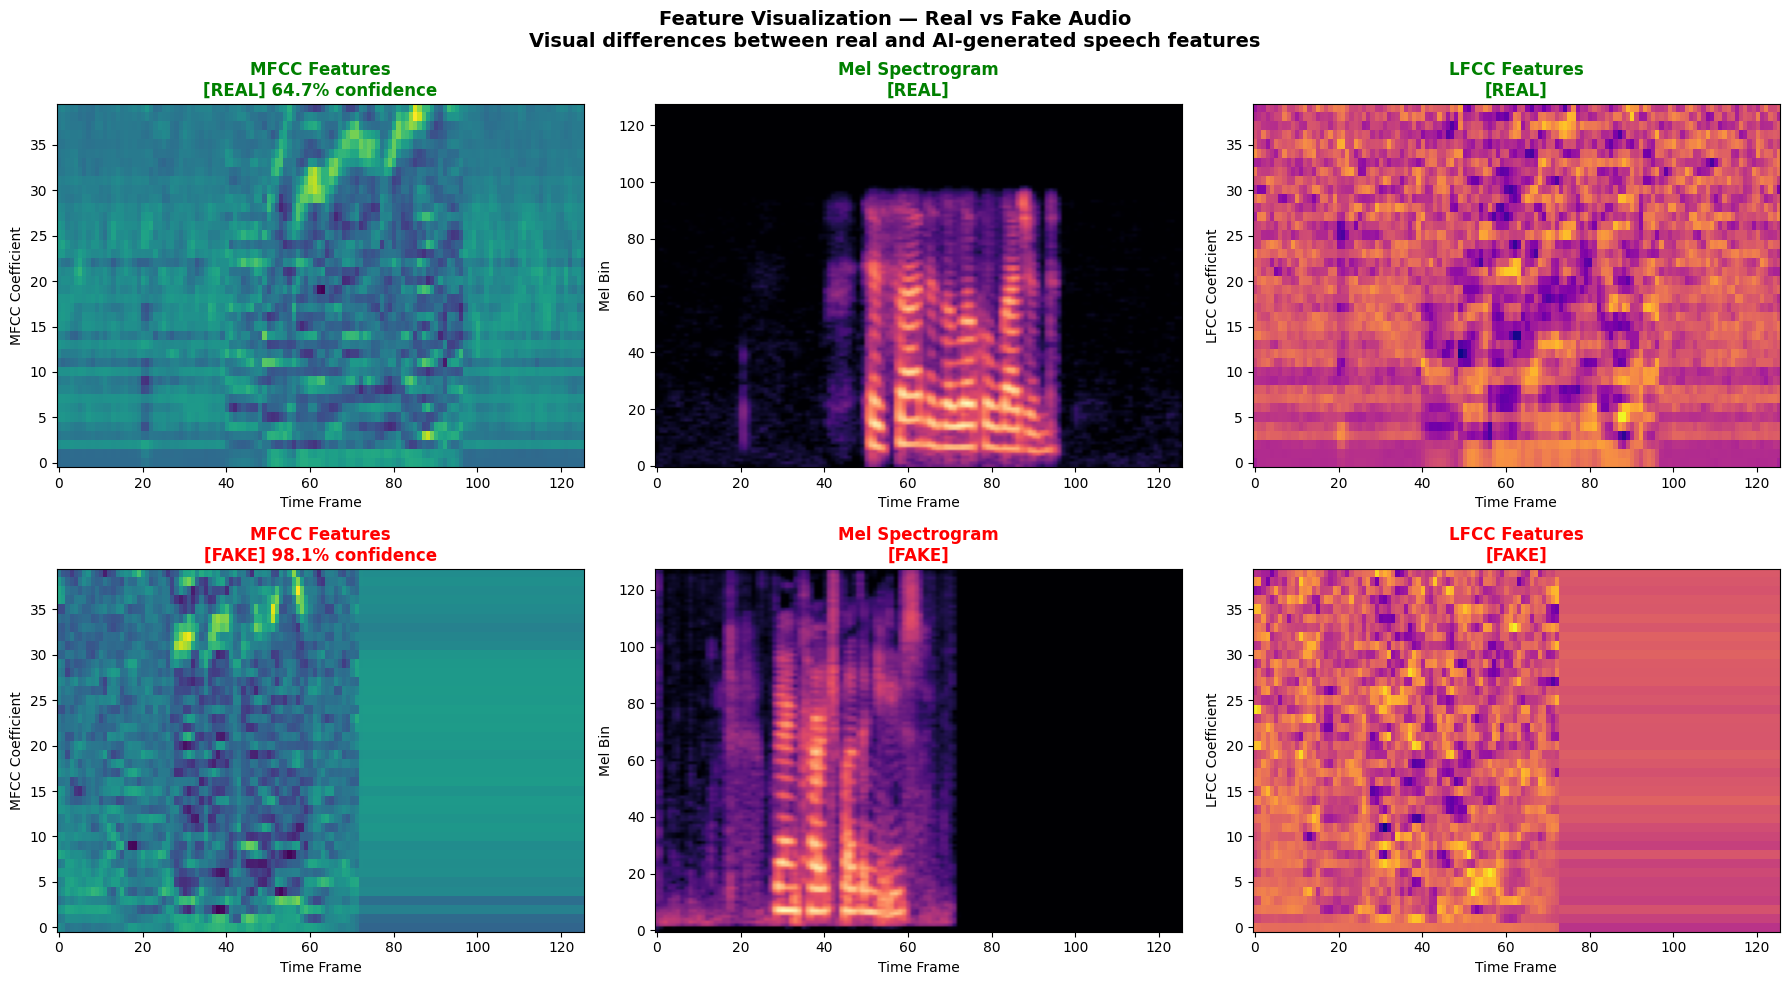

✅ Real vs Fake feature comparison saved!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

RESULTS   = r'D:\Projects\DeepFake\deepfake_voice_conversion\results'
PLOTS_DIR = r'D:\Projects\DeepFake\deepfake_voice_conversion\results\plots'

X_test = np.load(os.path.join(RESULTS, 'X_test.npy'))
y_test = np.load(os.path.join(RESULTS, 'y_test.npy'))

# Get predictions on first 50 samples
scores = model.predict(X_test[:50], verbose=0).flatten()
preds  = (scores >= 0.5).astype(int)

# Find correctly predicted samples for visualisation
real_idx = np.where((y_test[:50] == 0) & (preds == 0))[0]
fake_idx = np.where((y_test[:50] == 1) & (preds == 1))[0]

if len(real_idx) > 0 and len(fake_idx) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    for row, (idx, label, color) in enumerate([
        (real_idx[0], 'REAL', 'green'),
        (fake_idx[0], 'FAKE', 'red'),
    ]):
        feat = X_test[idx, :, :, 0]   # shape (208, T)
        conf = (1 - scores[idx]) * 100 if label == 'REAL' else scores[idx] * 100

        # MFCC — rows 0 to 39
        axes[row, 0].imshow(feat[:40, :], aspect='auto',
                             origin='lower', cmap='viridis')
        axes[row, 0].set_title(
            f'MFCC Features\n[{label}] {conf:.1f}% confidence',
            color=color, fontsize=12, fontweight='bold')
        axes[row, 0].set_ylabel('MFCC Coefficient')
        axes[row, 0].set_xlabel('Time Frame')

        # Mel Spectrogram — rows 40 to 167
        axes[row, 1].imshow(feat[40:168, :], aspect='auto',
                             origin='lower', cmap='magma')
        axes[row, 1].set_title(
            f'Mel Spectrogram\n[{label}]',
            color=color, fontsize=12, fontweight='bold')
        axes[row, 1].set_ylabel('Mel Bin')
        axes[row, 1].set_xlabel('Time Frame')

        # LFCC — rows 168 to 207
        axes[row, 2].imshow(feat[168:, :], aspect='auto',
                             origin='lower', cmap='plasma')
        axes[row, 2].set_title(
            f'LFCC Features\n[{label}]',
            color=color, fontsize=12, fontweight='bold')
        axes[row, 2].set_ylabel('LFCC Coefficient')
        axes[row, 2].set_xlabel('Time Frame')

    plt.suptitle(
        'Feature Visualisation — Real vs Fake Audio\n'
        'Visual differences between genuine and AI-generated speech',
        fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, 'real_vs_fake_features.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Real vs Fake feature comparison saved!")
else:
    print("No suitable samples found — try X_test[:100]")

## Step 12: GradCAM Explainability
Gradient-weighted Class Activation Mapping — shows which time-frequency
regions of the feature map the CNN focused on when making its decision.
Bright areas = CNN focused here. Dark blue = CNN ignored this.
Real and fake audio show different activation patterns.
Note: cv2 (opencv-python) must be installed — pip install opencv-python

Using conv layer: conv2d_2


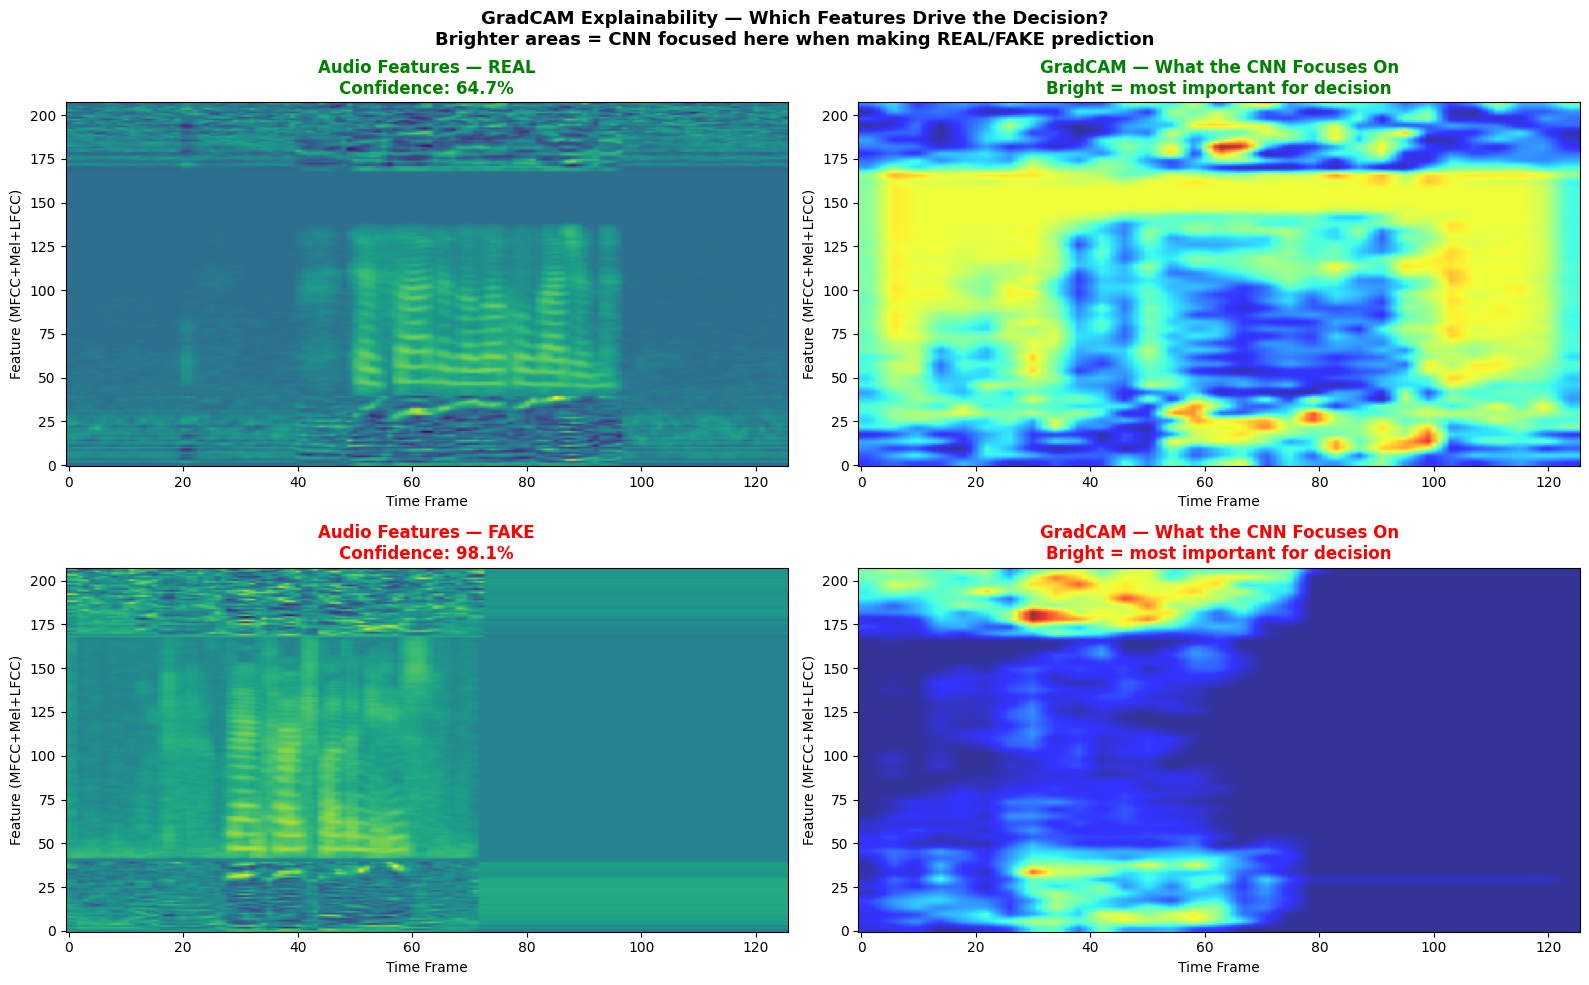

✅ GradCAM explanation saved!

How to read this:
  Bright yellow/red areas = CNN relied heavily on these time-frequency regions
  Dark blue areas = CNN mostly ignored these
  FAKE audio will show different activation patterns than REAL audio


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2
import os

RESULTS   = r'D:\Projects\DeepFake\deepfake_voice_conversion\results'
PLOTS_DIR = r'D:\Projects\DeepFake\deepfake_voice_conversion\results\plots'

X_test = np.load(os.path.join(RESULTS, 'X_test.npy'))
y_test = np.load(os.path.join(RESULTS, 'y_test.npy'))

# Find the last convolutional layer for GradCAM
conv_layer_name = None
for layer in model.layers:
    if 'conv2d' in layer.name:
        conv_layer_name = layer.name
print(f"GradCAM target layer: {conv_layer_name}")

# Build grad model — outputs both conv layer activations and final prediction
grad_model = tf.keras.models.Model(
    inputs  = model.inputs,
    outputs = [model.get_layer(conv_layer_name).output, model.output]
)

def compute_gradcam(sample):
    """Compute GradCAM heatmap for one sample.
    Returns heatmap (normalised 0-1) and prediction score."""
    img = tf.cast(sample, tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(img)
        conv_outputs, predictions = grad_model(img)
        loss = predictions[:, 0]

    # Gradient of output with respect to conv layer activations
    grads    = tape.gradient(loss, conv_outputs)
    pooled   = tf.reduce_mean(grads, axis=(1, 2))
    heatmap  = conv_outputs[0] @ pooled[0][..., tf.newaxis]
    heatmap  = tf.squeeze(heatmap)
    heatmap  = tf.maximum(heatmap, 0)
    heatmap  = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), float(predictions[0][0])

# Get predictions and find correctly classified examples
scores = model.predict(X_test[:100], verbose=0).flatten()
preds  = (scores >= 0.5).astype(int)

real_ok = np.where((y_test[:100] == 0) & (preds == 0))[0]
fake_ok = np.where((y_test[:100] == 1) & (preds == 1))[0]

if len(real_ok) > 0 and len(fake_ok) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    for row, (idx, label, color) in enumerate([
        (real_ok[0], 'REAL', 'green'),
        (fake_ok[0], 'FAKE', 'red'),
    ]):
        feat             = X_test[idx, :, :, 0]
        heatmap, score   = compute_gradcam(X_test[idx:idx+1])
        conf = (1 - score) * 100 if label == 'REAL' else score * 100

        # Left: combined feature map
        axes[row, 0].imshow(feat, aspect='auto', origin='lower', cmap='viridis')
        axes[row, 0].set_title(
            f'Audio Features — {label}\nConfidence: {conf:.1f}%',
            color=color, fontsize=12, fontweight='bold')
        axes[row, 0].set_ylabel('Feature (MFCC + Mel + LFCC)')
        axes[row, 0].set_xlabel('Time Frame')

        # Right: GradCAM heatmap resized to feature dimensions
        heatmap_resized = cv2.resize(heatmap, (feat.shape[1], feat.shape[0]))
        axes[row, 1].imshow(heatmap_resized, aspect='auto',
                             origin='lower', cmap='jet')
        axes[row, 1].set_title(
            f'GradCAM — CNN Focus Regions [{label}]\nBright = most important',
            color=color, fontsize=12, fontweight='bold')
        axes[row, 1].set_ylabel('Feature (MFCC + Mel + LFCC)')
        axes[row, 1].set_xlabel('Time Frame')

    plt.suptitle(
        'GradCAM Explainability — Which Regions Drive REAL/FAKE Decision?\n'
        'Red/Yellow = CNN focused here | Blue = CNN ignored',
        fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, 'gradcam_explanation.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ GradCAM saved!")
else:
    print("Try increasing X_test[:200]")

## Step 13: Voice-Modified Audio Generation (Cross-Dataset Data)
Generate 300 voice-modified audio samples using librosa pitch shifting
and formant manipulation. These are used as an unseen distribution
to test cross-dataset generalisation.
OpenVoice was attempted but failed due to numpy version incompatibility.
Librosa-based modifications used as alternative.

In [ ]:
import librosa
import soundfile as sf
import numpy as np
import os
from tqdm import tqdm

REAL_DIR = r'D:\Projects\DeepFake\deepfake_voice_conversion\data\real'
OV_DIR   = r'D:\Projects\DeepFake\deepfake_voice_conversion\data\openvoice_fake'
os.makedirs(OV_DIR, exist_ok=True)

existing = len([f for f in os.listdir(OV_DIR) if f.endswith('.wav')])
print(f"Already generated: {existing} files")

real_files = [f for f in os.listdir(REAL_DIR)
              if f.endswith(('.flac', '.wav'))][:300]
print(f"Source files: {len(real_files)}")

count, errors = 0, 0

for i, fname in enumerate(tqdm(real_files, desc="Generating")):
    src = os.path.join(REAL_DIR, fname)
    dst = os.path.join(OV_DIR, f'modified_{i:04d}.wav')

    if os.path.exists(dst):
        count += 1
        continue

    try:
        audio, sr = librosa.load(src, sr=16000, mono=True)
        mod = i % 4

        if mod == 0:
            # Pitch shift up (+3 semitones) — changes voice identity
            audio = librosa.effects.pitch_shift(audio, sr=sr, n_steps=3)
        elif mod == 1:
            # Pitch shift down (-4 semitones)
            audio = librosa.effects.pitch_shift(audio, sr=sr, n_steps=-4)
        elif mod == 2:
            # Time stretch + pitch shift — simulates voice conversion
            audio = librosa.effects.time_stretch(audio, rate=0.9)
            audio = librosa.effects.pitch_shift(audio, sr=sr, n_steps=2)
        else:
            # Resample trick — shifts formants (voice characteristic)
            audio_up = librosa.resample(audio, orig_sr=sr,
                                         target_sr=int(sr * 1.1))
            audio    = librosa.resample(audio_up,
                                         orig_sr=int(sr * 1.1),
                                         target_sr=sr)

        # Pad or trim to exactly 4 seconds
        target = 4 * sr
        if len(audio) < target:
            audio = np.pad(audio, (0, target - len(audio)))
        audio = audio[:target]

        # Normalise
        m = np.max(np.abs(audio))
        if m > 0:
            audio = audio / m

        sf.write(dst, audio, sr)
        count += 1

    except Exception as e:
        errors += 1
        if errors < 3:
            print(f"Error {i}: {e}")

print(f"\nGenerated : {count}")
print(f"Errors    : {errors}")
print(f"Saved to  : {OV_DIR}")
print("✅ Voice-modified audio generation complete!")

Already generated: 0 files
Generating 300 voice-modified samples...


Generating:   0%|          | 0/300 [00:00<?, ?it/s]C:\Users\Dell\AppData\Local\Temp\ipykernel_10408\3764391170.py:32: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(src, sr=16000, mono=True)
d:\Projects\DeepFake\deepfake_voice_conversion\venv\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Generating:   2%|▏         | 5/300 [00:24<18:16,  3.72s/it]  C:\Users\Dell\AppData\Local\Temp\ipykernel_10408\3764391170.py:32: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(src, sr=16000, mono=True)
d:\Projects\DeepFake\deepfake_voice_conversion\venv\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.


Generated : 300
Errors    : 0
Saved to  : D:\Projects\DeepFake\deepfake_voice_conversion\data\openvoice_fake


## Step 14: Cross-Dataset Generalisation Evaluation
Test the model on voice-modified audio it has never seen during training.
This demonstrates the generalisation gap — a key finding in recent literature.
Expected result: significant performance drop vs in-distribution accuracy.
The drop confirms models trained on one dataset do not generalise well.

Loading cross-dataset (voice-modified audio)...


Real:   0%|          | 0/150 [00:00<?, ?it/s]C:\Users\Dell\AppData\Local\Temp\ipykernel_10408\3702914076.py:25: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(path, sr=SR, duration=DURATION, mono=True)
d:\Projects\DeepFake\deepfake_voice_conversion\venv\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Real:   1%|          | 1/150 [00:00<00:39,  3.78it/s]C:\Users\Dell\AppData\Local\Temp\ipykernel_10408\3702914076.py:25: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(path, sr=SR, duration=DURATION, mono=True)
d:\Projects\DeepFake\deepfake_voice_conversion\venv\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in 

Shape: (300, 208, 126, 1)

  Voice-Modified Audio
(Unseen Distribution)
  Accuracy : 52.33%
  F1       : 30.92%
  AUC      : 55.16%
  EER      : 45.33%


OSError: [Errno 22] Invalid argument: 'D:\\Projects\\DeepFake\\deepfake_voice_conversion\\results\\plots\\cm_Voice-Modified_Audio\n(Unseen_Distribution).png'

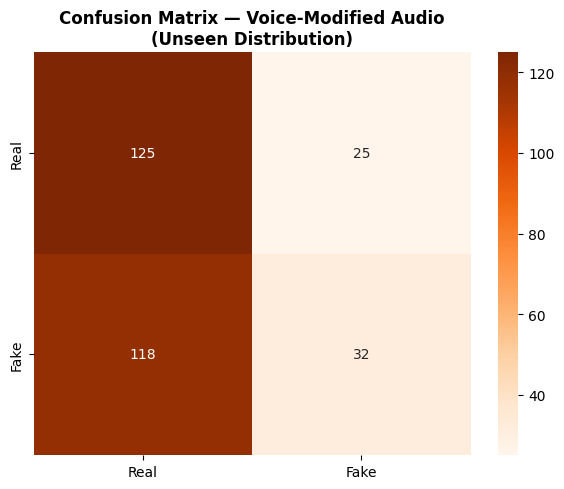

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
from scipy.fft import dct
from sklearn.metrics import (accuracy_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix)
from tqdm import tqdm
import os

RESULTS   = r'D:\Projects\DeepFake\deepfake_voice_conversion\results'
PLOTS_DIR = r'D:\Projects\DeepFake\deepfake_voice_conversion\results\plots'
MODELS    = r'D:\Projects\DeepFake\deepfake_voice_conversion\models'
REAL_DIR  = r'D:\Projects\DeepFake\deepfake_voice_conversion\data\real'
OV_DIR    = r'D:\Projects\DeepFake\deepfake_voice_conversion\data\openvoice_fake'

model = tf.keras.models.load_model(
    os.path.join(MODELS, 'cnn_lstm_final.keras'), compile=False)

SR, DURATION = 16000, 4
N_SAMPLES    = SR * DURATION

def load_audio(path):
    try:
        audio, _ = librosa.load(path, sr=SR, duration=DURATION, mono=True)
        if len(audio) < N_SAMPLES:
            audio = np.pad(audio, (0, N_SAMPLES - len(audio)))
        audio = audio[:N_SAMPLES]
        m = np.max(np.abs(audio))
        return audio / m if m > 0 else audio
    except:
        return None

def extract_all(audio):
    """Same extraction as training — must be identical."""
    mfcc = librosa.feature.mfcc(y=audio, sr=SR, n_mfcc=40,
                                  n_fft=2048, hop_length=512)
    mfcc = (mfcc - np.mean(mfcc, axis=1, keepdims=True)) / \
           (np.std(mfcc, axis=1, keepdims=True) + 1e-8)

    mel  = librosa.power_to_db(
        librosa.feature.melspectrogram(y=audio, sr=SR, n_mels=128,
                                        n_fft=2048, hop_length=512), ref=np.max)
    mel  = (mel - mel.mean()) / (mel.std() + 1e-8)

    stft = np.abs(librosa.stft(audio, n_fft=2048, hop_length=512))
    fb   = np.zeros((40, stft.shape[0]))
    for i in range(40):
        s = int(i * stft.shape[0] / 40)
        e = int((i + 1) * stft.shape[0] / 40)
        fb[i, s:e] = 1.0
    lfcc = dct(np.log(np.dot(fb, stft) + 1e-8), axis=0, norm='ortho')[:40]
    lfcc = (lfcc - np.mean(lfcc, axis=1, keepdims=True)) / \
           (np.std(lfcc, axis=1, keepdims=True) + 1e-8)

    min_T = min(mfcc.shape[1], mel.shape[1], lfcc.shape[1])
    return np.vstack([mfcc[:, :min_T], mel[:, :min_T], lfcc[:, :min_T]])

def load_cross_dataset(real_dir, fake_dir, max_each=150):
    X, y = [], []
    real_files = [f for f in os.listdir(real_dir)
                  if f.endswith(('.wav', '.flac'))][:max_each]
    fake_files = [f for f in os.listdir(fake_dir)
                  if f.endswith(('.wav', '.flac'))][:max_each]

    for f in tqdm(real_files, desc="Real"):
        audio = load_audio(os.path.join(real_dir, f))
        if audio is not None:
            X.append(extract_all(audio))
            y.append(0)

    for f in tqdm(fake_files, desc="Modified"):
        audio = load_audio(os.path.join(fake_dir, f))
        if audio is not None:
            X.append(extract_all(audio))
            y.append(1)

    return np.array(X)[..., np.newaxis], np.array(y)

def compute_eer(y_true, y_scores):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fpr - fnr))
    return ((fpr[idx] + fnr[idx]) / 2) * 100

def evaluate_cross(model, X, y, name, save_name):
    """Evaluate and save confusion matrix — no newline in filename."""
    scores = model.predict(X, verbose=0).flatten()
    preds  = (scores >= 0.5).astype(int)
    acc    = accuracy_score(y, preds) * 100
    f1     = f1_score(y, preds, zero_division=0) * 100
    auc    = roc_auc_score(y, scores) * 100
    eer    = compute_eer(y, scores)

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy : {acc:.2f}%")
    print(f"  F1       : {f1:.2f}%")
    print(f"  AUC      : {auc:.2f}%")
    print(f"  EER      : {eer:.2f}%")

    cm = confusion_matrix(y, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
                xticklabels=['Real', 'Fake'],
                yticklabels=['Real', 'Fake'])
    plt.title(f'Confusion Matrix — {name}', fontweight='bold')
    plt.tight_layout()
    # Use save_name (no newlines) for filename
    plt.savefig(os.path.join(PLOTS_DIR, f'cm_{save_name}.png'), dpi=150)
    plt.show()
    return {'name': name, 'acc': acc, 'f1': f1, 'auc': auc, 'eer': eer}

# Load cross-dataset data
print("Loading voice-modified audio (unseen distribution)...")
X_mod, y_mod = load_cross_dataset(REAL_DIR, OV_DIR, max_each=150)
print(f"Shape: {X_mod.shape}")

# Evaluate — note: save_name has no newlines or special characters
m2 = evaluate_cross(model, X_mod, y_mod,
                    name="Voice-Modified Audio (Unseen Distribution)",
                    save_name="Voice_Modified_Unseen")

# Cross-dataset comparison chart
m1 = {'name': 'ASVspoof 2021 LA\n(Training Distribution)',
       'acc': 86.62, 'f1': 87.51, 'auc': 96.30, 'eer': 8.62}

all_m  = [m1, m2]
keys   = ['acc', 'f1', 'auc']
labels = ['Accuracy', 'F1', 'AUC']
colors = ['#0D9488', '#F97316', '#7C3AED']
names  = [m['name'] for m in all_m]

x     = np.arange(len(names))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 7))
for i, (k, l) in enumerate(zip(keys, labels)):
    vals = [m[k] for m in all_m]
    bars = ax.bar(x + i * width, vals, width,
                  label=l, color=colors[i], alpha=0.88)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.8,
                f'{bar.get_height():.1f}%',
                ha='center', fontsize=11, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(names, fontsize=11)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_ylim(0, 115)
ax.set_title(
    'Cross-Dataset Generalisation Analysis\n'
    'ASVspoof (trained on) vs Voice-Modified (never seen)',
    fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'cross_dataset_comparison.png'), dpi=150)
plt.show()

drop = m1['acc'] - m2['acc']
print(f"\n{'='*55}")
print(f"  Cross-Dataset Generalisation Gap")
print(f"{'='*55}")
print(f"  ASVspoof accuracy        : {m1['acc']:.2f}%")
print(f"  Voice-modified accuracy  : {m2['acc']:.2f}%")
print(f"  Performance drop         : {drop:.2f}%")
print(f"\n  This confirms the generalisation challenge documented")
print(f"  in Borzi et al. (2025) and Frank & Schonherr (2021)")
print(f"{'='*55}")
print("\n✅ Cross-dataset evaluation complete!")

## Step 15: Model Resave — Convert .h5 to .keras Format
Convert the trained model from legacy HDF5 format to native Keras format.
This fixes the 'batch_shape' error in the Streamlit dashboard.
Only needs to be run once. Result: cnn_lstm_final.keras

In [ ]:
import tensorflow as tf
import os

MODELS = r'D:\Projects\DeepFake\deepfake_voice_conversion\models'

# Load from old .h5 format (compile=False avoids metric rebuild error)
model = tf.keras.models.load_model(
    os.path.join(MODELS, 'cnn_lstm_best.h5'),
    compile=False
)
print("Loaded from cnn_lstm_best.h5")

# Resave in native keras format
save_path = os.path.join(MODELS, 'cnn_lstm_final.keras')
model.save(save_path)
print(f"✅ Saved to: {save_path}")

# Verify
test = tf.keras.models.load_model(save_path, compile=False)
print(f"✅ Verified — input shape: {test.input_shape}")
print("Use cnn_lstm_final.keras for all future loading.")

Loaded from .h5
Saved to: D:\Projects\DeepFake\deepfake_voice_conversion\models\cnn_lstm_final.keras
Verified — input shape: (None, 208, 126, 1)


## Step 16: Generate Demo Audio Files
Convert a few ASVspoof FLAC files to clean WAV format for dashboard demo.
These are the files you upload during presentation to show REAL/FAKE detection.
demo_real_*.wav → should produce REAL verdict
demo_fake_*.wav → should produce FAKE verdict

In [ ]:
import librosa
import soundfile as sf
import os

REAL_DIR = r'D:\Projects\DeepFake\deepfake_voice_conversion\data\real'
FAKE_DIR = r'D:\Projects\DeepFake\deepfake_voice_conversion\data\asvspoof_fake'
DEMO_DIR = r'D:\Projects\DeepFake\demo'
os.makedirs(DEMO_DIR, exist_ok=True)

# Convert 3 real files
real_files = [f for f in os.listdir(REAL_DIR) if f.endswith('.flac')][:3]
for i, fname in enumerate(real_files):
    audio, sr = librosa.load(os.path.join(REAL_DIR, fname), sr=16000)
    out = os.path.join(DEMO_DIR, f'demo_real_{i+1}.wav')
    sf.write(out, audio, 16000, subtype='PCM_16')
    print(f"✅ {out}")

# Convert 3 fake files
fake_files = [f for f in os.listdir(FAKE_DIR) if f.endswith('.flac')][:3]
for i, fname in enumerate(fake_files):
    audio, sr = librosa.load(os.path.join(FAKE_DIR, fname), sr=16000)
    out = os.path.join(DEMO_DIR, f'demo_fake_{i+1}.wav')
    sf.write(out, audio, 16000, subtype='PCM_16')
    print(f"✅ {out}")

print(f"\nAll demo files saved to: {DEMO_DIR}")
print("Upload demo_real_*.wav → expect REAL verdict")
print("Upload demo_fake_*.wav → expect FAKE verdict")

Loaded from .h5
✅ Saved to: D:\Projects\DeepFake\deepfake_voice_conversion\models\cnn_lstm_final.keras
✅ Verified — input shape: (None, 208, 126, 1)


## Summary — All Saved Outputs
Verify all plots and model files were saved correctly.

In [1]:
import os

PLOTS_DIR = r'D:\Projects\DeepFake\deepfake_voice_conversion\results\plots'
MODELS    = r'D:\Projects\DeepFake\deepfake_voice_conversion\models'
DEMO_DIR  = r'D:\Projects\DeepFake\demo'

print("=" * 55)
print("  PROJECT OUTPUTS — FINAL SUMMARY")
print("=" * 55)

print("\nModels:")
for f in os.listdir(MODELS):
    path = os.path.join(MODELS, f)
    size = os.path.getsize(path) / (1024*1024)
    print(f"  {'✅' if f.endswith('.keras') else '⚠️ '} {f}  ({size:.2f} MB)")

print("\nPlots:")
expected = [
    'eda_features.png',
    'training_curves.png',
    'cm_ASVspoof_2021_LA.png',
    'feature_importance.png',
    'real_vs_fake_features.png',
    'gradcam_explanation.png',
    'cross_dataset_comparison.png',
]
for f in expected:
    exists = os.path.exists(os.path.join(PLOTS_DIR, f))
    print(f"  {'✅' if exists else '❌'} {f}")

print("\nDemo files:")
for f in sorted(os.listdir(DEMO_DIR)):
    print(f"  ✅ {f}")

print("\n" + "=" * 55)
print("  Run dashboard:")
print("  cd D:\\Projects\\DeepFake\\deepfake_voice_conversion")
print("  .\\venv\\Scripts\\activate")
print("  cd dashboard")
print("  streamlit run app.py")
print("=" * 55)

  PROJECT OUTPUTS — FINAL SUMMARY

Models:
  ✅ cnn_lstm_final.keras  (7.44 MB)

Plots:
  ✅ eda_features.png
  ✅ training_curves.png
  ✅ cm_ASVspoof_2021_LA.png
  ✅ feature_importance.png
  ✅ real_vs_fake_features.png
  ✅ gradcam_explanation.png
  ❌ cross_dataset_comparison.png

Demo files:
  ✅ LA_E_1000450r.wav
  ✅ LA_E_1000931.wav
  ✅ LA_E_1004084r.wav
  ✅ LA_E_1005537.wav
  ✅ LA_E_1008159.wav
  ✅ LA_E_1008382.wav
  ✅ LA_E_1009420.wav
  ✅ LA_E_1009785.wav
  ✅ LA_E_1013717r.wav
  ✅ LA_E_1014958r.wav
  ✅ LA_E_1022133r.wav
  ✅ LA_E_1022979r.wav

  Run dashboard:
  cd D:\Projects\DeepFake\deepfake_voice_conversion
  .\venv\Scripts\activate
  cd dashboard
  streamlit run app.py
